In [1]:
import numpy as np
import pandas as pds
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
from alpha_vantage.timeseries import TimeSeries

# api_key = 'YOUR_ALPHA_VANTAGE_API_KEY'
api_key = 'SSW9AMG17A9Y5BBA'

In [3]:
ts = TimeSeries(key=api_key, output_format='pandas')

In [4]:
# NOTE: the free Alpha Vantage tier no longer covers what this cell used:
#   - get_daily_adjusted(...)            -> premium endpoint entirely
#   - get_daily(..., outputsize='full')  -> 'full' is a premium parameter too
# Free options that still work (verified 2026-09):
#   - get_daily('AMZN', outputsize='compact') -> last 100 trading days
#   - get_monthly('AMZN')                     -> full history since 1999, monthly bars
# amzn, _ = ts.get_monthly('AMZN')  # uncomment for full history, monthly bars

amzn, _ = ts.get_daily(symbol='AMZN', outputsize='compact')  # last ~100 trading days
amzn

,1. open,2. high,3. low,4. close,5. volume
date,,,,,
2026-10-01,251.605,251.8300,246.1167,248.23,33243918.0
2026-09-30,246.790,252.4400,246.0800,249.15,41913110.0
2026-09-29,246.705,248.8389,245.1400,246.67,33730401.0
2026-09-28,246.625,247.7699,244.7250,246.15,32596709.0
2026-09-25,248.560,250.8775,247.1800,249.67,34263902.0
...,...,...,...,...,...
2026-05-15,262.500,264.3550,260.8901,264.14,40770344.0
2026-05-14,269.150,270.7799,266.6300,267.22,31338435.0
2026-05-13,264.430,270.7200,263.2000,270.13,39670915.0


In [5]:
amzn.columns = ['OPEN AMZN', 'HIGH AMZN', 'LOW AMZN', 'CLOSE AMZN', 'VOLUME AMZN']
amzn 

,OPEN AMZN,HIGH AMZN,LOW AMZN,CLOSE AMZN,VOLUME AMZN
date,,,,,
2026-10-01,251.605,251.8300,246.1167,248.23,33243918.0
2026-09-30,246.790,252.4400,246.0800,249.15,41913110.0
2026-09-29,246.705,248.8389,245.1400,246.67,33730401.0
2026-09-28,246.625,247.7699,244.7250,246.15,32596709.0
2026-09-25,248.560,250.8775,247.1800,249.67,34263902.0
...,...,...,...,...,...
2026-05-15,262.500,264.3550,260.8901,264.14,40770344.0
2026-05-14,269.150,270.7799,266.6300,267.22,31338435.0
2026-05-13,264.430,270.7200,263.2000,270.13,39670915.0


In [6]:
amzn = amzn.sort_index(axis=0, ascending=True)
pctamzn = amzn.pct_change().dropna()
pctamzn

,OPEN AMZN,HIGH AMZN,LOW AMZN,CLOSE AMZN,VOLUME AMZN
date,,,,,
2026-05-12,-0.011581,-0.021854,-0.021789,-0.011785,-0.036684
2026-05-13,-0.008549,0.011470,0.002170,0.016214,0.078711
2026-05-14,0.017850,0.000221,0.013032,-0.010773,-0.210040
2026-05-15,-0.024707,-0.023727,-0.021528,-0.011526,0.300969
2026-05-18,0.005200,0.017004,0.006286,0.002726,-0.173645
...,...,...,...,...,...
2026-09-25,0.010324,0.001787,0.006433,0.001163,0.037041
2026-09-28,-0.007785,-0.012387,-0.009932,-0.014099,-0.048657
2026-09-29,0.000324,0.004314,0.001696,0.002113,0.034779


### Set of data

In [17]:
a = 3900
l = len(amzn)
# a must fit the actual data length: compact daily data only has ~100 rows
# l = len(amzn)
# a = int(l * 0.9)  # first 90% to train on, last 10% to visualize

X_train = amzn.iloc[0:a-1, 0:].values
y_train = amzn[["CLOSE AMZN"]].iloc[1:a:].values

X_visu = amzn.iloc[a:l-1:].values
y_visu = amzn[["CLOSE AMZN"]].iloc[a+1:l,:].values

# print(f"{l} rows total -> X_train: {X_train.shape}, y_train: {y_train.shape}, X_visu: {X_visu.shape}, y_visu: {y_visu.shape}")

amzn

,OPEN AMZN,HIGH AMZN,LOW AMZN,CLOSE AMZN,VOLUME AMZN
date,,,,,
2026-05-11,269.835,273.6300,268.4800,268.99,38176696.0
2026-05-12,266.710,267.6500,262.6300,265.82,36776221.0
2026-05-13,264.430,270.7200,263.2000,270.13,39670915.0
2026-05-14,269.150,270.7799,266.6300,267.22,31338435.0
2026-05-15,262.500,264.3550,260.8901,264.14,40770344.0
...,...,...,...,...,...
2026-09-25,248.560,250.8775,247.1800,249.67,34263902.0
2026-09-28,246.625,247.7699,244.7250,246.15,32596709.0
2026-09-29,246.705,248.8389,245.1400,246.67,33730401.0


### Linear Regression

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
lr = LinearRegression()

In [10]:
# lr.fit(X_train, y_train)
print(lr.fit(X_train, y_train))

LinearRegression()


In [11]:
y_pred = lr.predict(X_visu)
y_pred
# print(y_pred)

array([[253.20180745],
       [253.63008415],
       [253.67601297],
       [253.57342401],
       [254.08803508],
       [254.03164679],
       [254.1084619 ],
       [254.05622759],
       [253.67921326]])

### Visualisation

[]

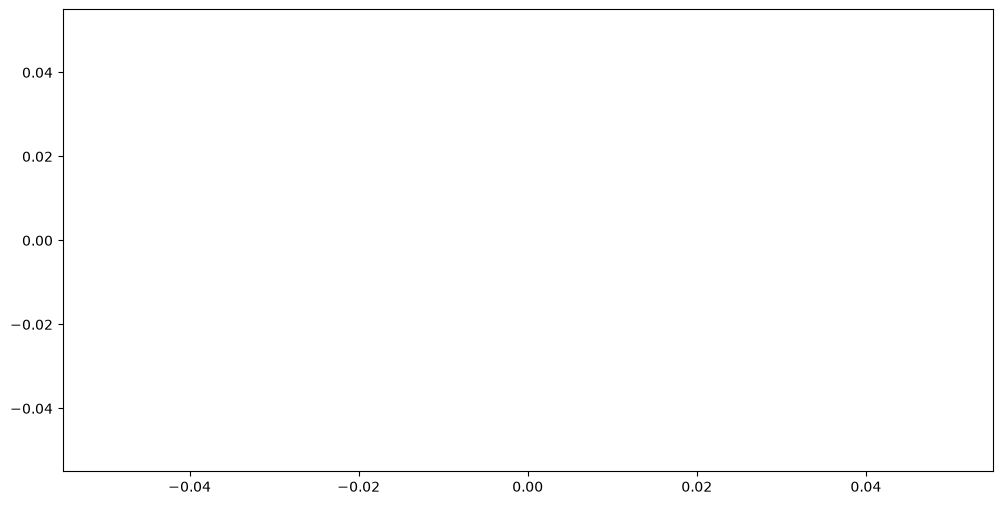

In [12]:
plt.figure(figsize=(12, 6))
plt.plot()